# Tangent-Linear vs Adjoint Methods

This notebook demonstrates two fundamental approaches for solving inverse problems in data assimilation:

1. Tangent Linear Method (Gauss-Newton)
2. Adjoint Method (Gradient Descent)
   
Both methods aim to find model parameters that minimize the misfit between model predictions and observations. 

In [1]:
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import mpltex
import numpy as np
import matplotlib.pyplot as plt
from fgpt.core.common.logger import Logger

params = {
    "font.family": "DejaVu Sans",
    "lines.linewidth": 2,
    "lines.dashed_pattern": [4, 2],
    "lines.dashdot_pattern": [6, 3, 2, 3],
    "lines.dotted_pattern": [2, 3],
    "mathtext.rm": "arial",
    "axes.labelsize": 15,
    "axes.titlesize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "legend.fontsize": 15,
    "legend.loc": "best",
    "legend.frameon": False,
    "xtick.direction": "out",
    "ytick.direction": "out",
}
mpl.rcParams.update(params)
logger = Logger()

## Forward Model Definition

Our forward model maps 10 parameters to 4 outputs through nonlinear functions:

In [2]:
def model(p):
    """
    Forward model: maps 10 parameters to 4 outputs
    
    Parameters:
    -----------
    p : array_like
        Vector of 10 parameters [p1, p2, ..., p10]
    
    Returns:
    --------
    np.ndarray
        Vector of 4 outputs [y1, y2, y3, y4]
    """
    p1, p2, p3, p4, p5, p6, p7, p8, p9, p10 = p
    
    y1 = p1**2 + np.sin(p2) + p3*p4
    y2 = np.exp(0.2*p5) + p1*p6 + p7**2
    y3 = p2*p5 + np.cos(p8) + p9
    y4 = p3**2 + p6*p10 + np.sin(p4)
    
    return np.array([y1, y2, y3, y4])

def jacobian(p):
    """
    Compute the Jacobian matrix of the forward model
    
    Parameters:
    -----------
    p : array_like
        Vector of 10 parameters
    
    Returns:
    --------
    np.ndarray
        4x10 Jacobian matrix
    """
    p1, p2, p3, p4, p5, p6, p7, p8, p9, p10 = p
    
    M = np.array([
        # y1 derivatives
        [2*p1, np.cos(p2), p4, p3, 0, 0, 0, 0, 0, 0],
        # y2 derivatives
        [p6, 0, 0, 0, 0.2*np.exp(0.2*p5), p1, 2*p7, 0, 0, 0],
        # y3 derivatives
        [0, p5, 0, 0, p2, 0, 0, -np.sin(p8), 1, 0],
        # y4 derivatives
        [0, 0, 2*p3, np.cos(p4), 0, p10, 0, 0, 0, p6]
    ])
    
    return M

## Model Analysis

Let's understand the behavior of our model by visualizing how parameters affect outputs.

In [3]:
import seaborn as sns

[INFO] Baseline parameters: [1.  0.5 0.8 0.3 1.2 0.7 0.4 0.6 0.9 0.5]

[INFO] Baseline outputs: [1.71942554 2.13124915 2.32533561 1.28552021]

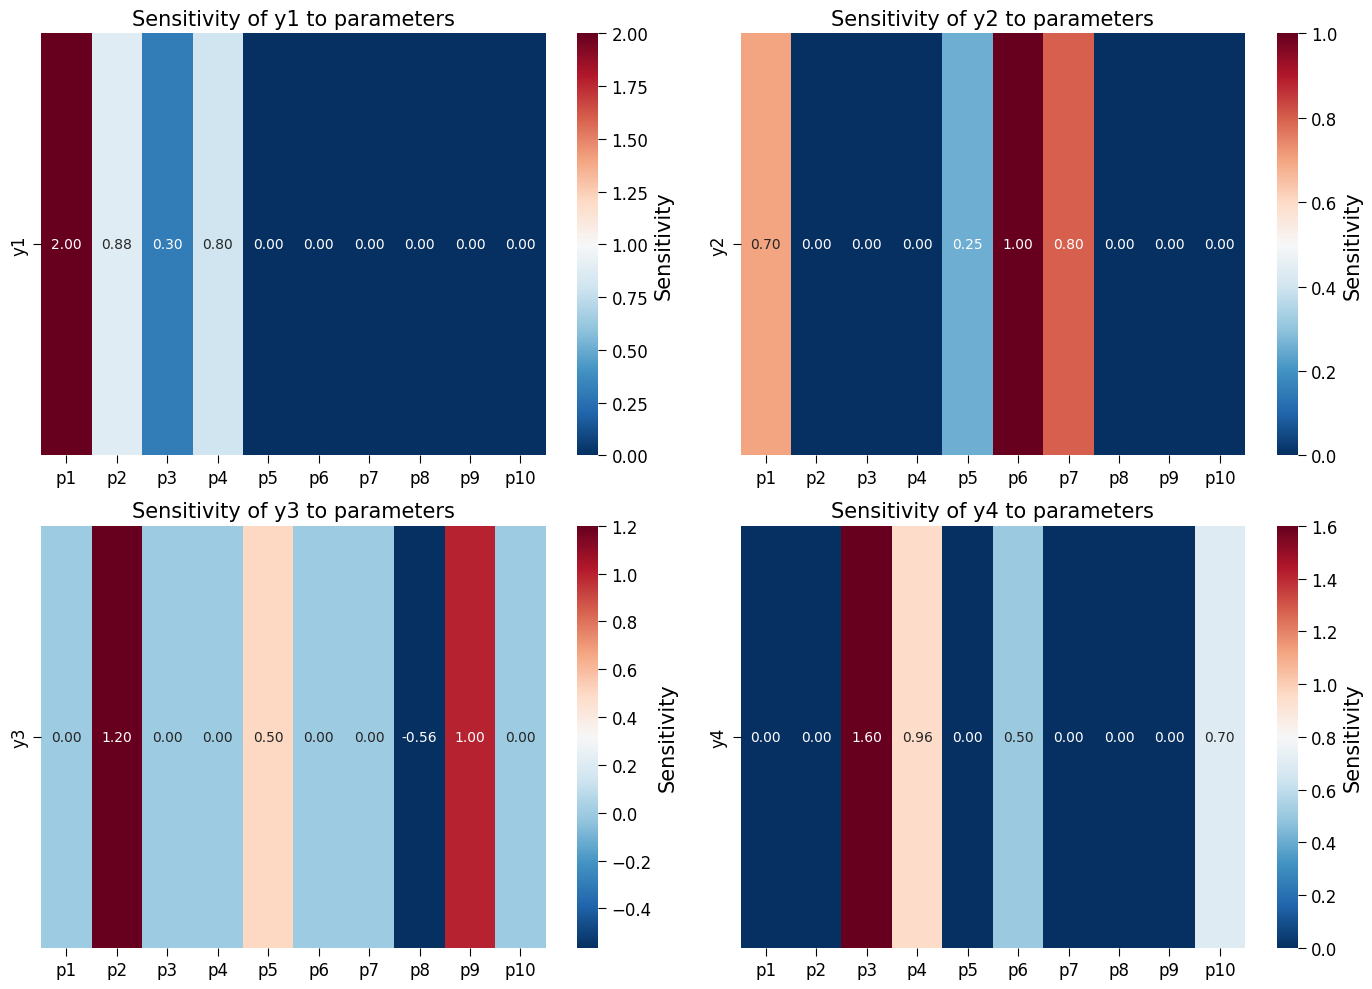

In [4]:
# Define a baseline parameter set
p_baseline = np.array([1.0, 0.5, 0.8, 0.3, 1.2, 0.7, 0.4, 0.6, 0.9, 0.5])
y_baseline = model(p_baseline)

logger.info(f"Baseline parameters: {p_baseline}")
logger.info(f"Baseline outputs: {y_baseline}")

# Create a sensitivity analysis
param_names = ['p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7', 'p8', 'p9', 'p10']
output_names = ['y1', 'y2', 'y3', 'y4']

sensitivity_matrix = jacobian(p_baseline)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, (ax, y_name) in enumerate(zip(axes.flatten(), output_names)):
    sns.heatmap(sensitivity_matrix[i:i+1, :], 
                ax=ax, 
                annot=True, 
                fmt='.2f',
                xticklabels=param_names,
                yticklabels=[y_name],
                cmap='RdBu_r',
                cbar_kws={'label': 'Sensitivity'})
    ax.set_title(f'Sensitivity of {y_name} to parameters')
plt.tight_layout()
plt.show()

## True System and Observations

We generate synthetic observations by running the model with known "true" parameters and adding observational noise.

In [5]:
# True parameters
p_true = np.array([1.0, 0.5, 0.8, 0.3, 1.2, 0.7, 0.4, 0.6, 0.9, 0.5])

# Generate observations (true outputs)
y_true = model(p_true)

# Add some noise to simulate real observations
np.random.seed(42)
noise_level = 0.05
y_obs = y_true + noise_level * np.random.randn(4)

logger.info(f"True parameters: {p_true}")
logger.info(f"True outputs: {y_true}")
logger.info(f"Observed outputs (with noise): {y_obs}")
logger.info(f"Noise level: {noise_level}")
logger.info(f"Observation error: {y_obs - y_true}")

[INFO] True parameters: [1.  0.5 0.8 0.3 1.2 0.7 0.4 0.6 0.9 0.5]

[INFO] True outputs: [1.71942554 2.13124915 2.32533561 1.28552021]

[INFO] Observed outputs (with noise): [1.74426125 2.12433594 2.35772004 1.3616717 ]

[INFO] Noise level: 0.05

[INFO] Observation error: [ 0.02483571 -0.00691322  0.03238443  0.07615149]

## Tangent Linear Method

The tangent linear method uses the linearized model to solve for parameter updates.

In [6]:
def calibrate_tangent(p0, y_obs, n_iter=20, verbose=True):
    """
    Calibrate parameters using the tangent linear (Gauss-Newton) method
    
    Parameters:
    -----------
    p0 : array_like
        Initial parameter guess
    y_obs : array_like
        Observed outputs
    n_iter : int
        Number of iterations
    verbose : bool
        logger.info progress information
    
    Returns:
    --------
    tuple
        (final parameters, history of cost and parameter norms)
    """
    p = p0.copy()
    cost_history = []
    p_norm_history = []
    
    for k in range(n_iter):
        # Forward model
        y = model(p)
        
        # Residual
        r = y - y_obs
        
        # Cost function
        J = 0.5 * np.dot(r, r)
        cost_history.append(J)
        
        # Jacobian
        M = jacobian(p)
        
        # Solve linear system: M * delta_p = -r
        # Using least squares since M may not be square
        delta_p = np.linalg.lstsq(M, -r, rcond=None)[0]
        p_norm_history.append(np.linalg.norm(delta_p))
        
        # Update parameters
        p = p + delta_p
        
        if verbose and (k % 2 == 0 or k == n_iter - 1):
            logger.info(f"Iteration {k:2d}: J = {J:.6e}, |delta_p| = {np.linalg.norm(delta_p):.6e}")
    
    return p, np.array(cost_history), np.array(p_norm_history)

## Adjoint Method

The adjoint method uses the gradient of the cost function with respect to parameters, computed via the adjoint of the Jacobian.

In [7]:
def calibrate_adjoint(p0, y_obs, n_iter=1000, alpha=0.01, verbose=True):
    """
    Calibrate parameters using the adjoint (gradient descent) method
    
    Parameters:
    -----------
    p0 : array_like
        Initial parameter guess
    y_obs : array_like
        Observed outputs
    n_iter : int
        Number of iterations
    alpha : float
        Learning rate
    verbose : bool
        logger.info progress information
    
    Returns:
    --------
    tuple
        (final parameters, history of cost and gradient norms)
    """
    p = p0.copy()
    cost_history = []
    grad_history = []
    
    for k in range(n_iter):
        # Forward model
        y = model(p)
        
        # Residual
        r = y - y_obs
        
        # Cost
        J = 0.5 * np.dot(r, r)
        cost_history.append(J)
        
        # Jacobian
        M = jacobian(p)
        
        # Adjoint: gradient of cost with respect to parameters
        gradient = M.T @ r
        grad_norm = np.linalg.norm(gradient)
        grad_history.append(grad_norm)
        
        # Gradient descent update
        p = p - alpha * gradient
        
        if verbose and (k % 100 == 0 or k == n_iter - 1):
            logger.info(f"Iteration {k:4d}: J = {J:.6e}, |gradient| = {grad_norm:.6e}")
    
    return p, np.array(cost_history), np.array(grad_history)

## Comparing the Two Methods

Let's run both calibration methods and compare their performance.

In [8]:
# Initial guess (far from truth)
p0 = np.random.uniform(0.1, 1.5, size=10)

logger.info(f"Initial parameters (guess): {p0}")
logger.info(f"Initial outputs: {model(p0)}")
logger.info(f"Observed outputs: {y_obs}")

logger.info("Tangent Linear Method (Gauss-Newton)")
p_TLM, cost_TLM, p_norm_TLM = calibrate_tangent(p0, y_obs, n_iter=10)

logger.info("Adjoint Method (Gradient Descent)")
p_ADJ, cost_ADJ, grad_ADJ = calibrate_adjoint(p0, y_obs, n_iter=2000, alpha=0.001)

[INFO] Initial parameters (guess): [0.3184261  0.31839233 0.18131706 1.3126466  0.94156102 1.09130161
 0.12881829 1.45787379 1.2654197  0.39727475]

[INFO] Initial outputs: [0.65244049 1.57130342 1.6778882  1.43328645]

[INFO] Observed outputs: [1.74426125 2.12433594 2.35772004 1.3616717 ]

[INFO] Tangent Linear Method (Gauss-Newton)

[INFO] Iteration  0: J = 9.826088e-01, |delta_p| = 7.476419e-01

...

[INFO] Iteration 1600: J = 3.660981e-04, |gradient| = 3.470399e-02

[INFO] Iteration 1700: J = 2.641575e-04, |gradient| = 2.921607e-02

[INFO] Iteration 1800: J = 1.917459e-04, |gradient| = 2.465548e-02

[INFO] Iteration 1900: J = 1.400545e-04, |gradient| = 2.085973e-02

[INFO] Iteration 1999: J = 1.032753e-04, |gradient| = 1.772473e-02

## Convergence Analysis

Let's analyze the convergence behavior of both methods.

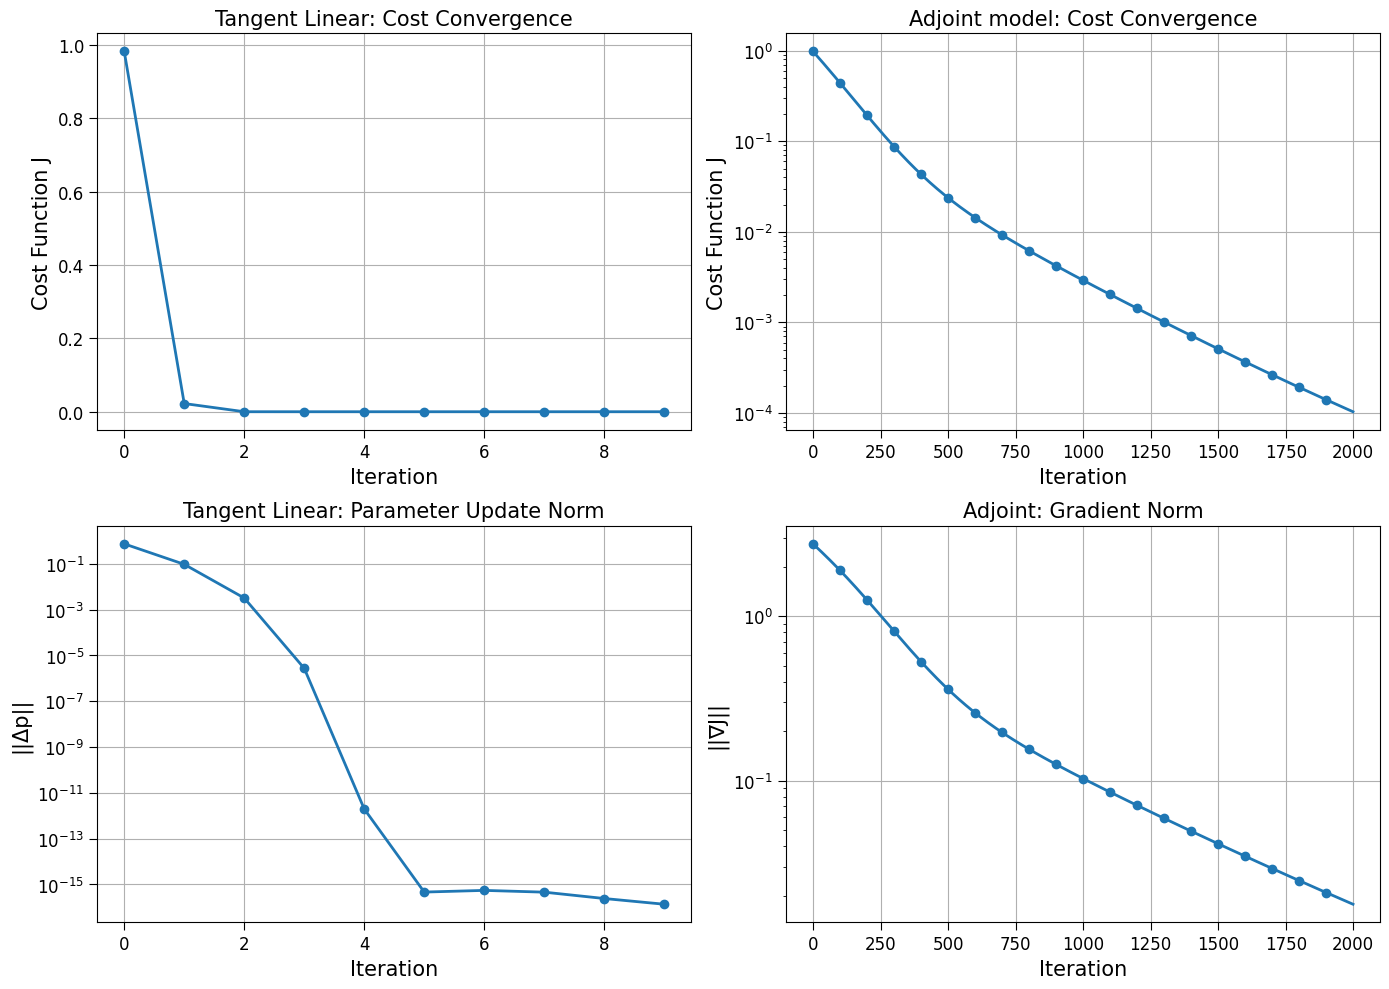

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
linestyles = mpltex.linestyle_generator()
ax.plot(cost_TLM, **next(linestyles))
ax.set_xlabel('Iteration')
ax.set_ylabel('Cost Function J')
ax.set_title('Tangent Linear: Cost Convergence')
ax.grid(True)

# Cost function convergence
linestyles = mpltex.linestyle_generator()
ax = axes[0, 1]
ax.semilogy(cost_ADJ, markevery=100, **next(linestyles))
ax.set_xlabel('Iteration')
ax.set_ylabel('Cost Function J')
ax.set_title('Adjoint model: Cost Convergence')
ax.grid(True)


# Parameter correction norm for TLM
ax = axes[1, 0]
linestyles = mpltex.linestyle_generator()
ax.semilogy(p_norm_TLM, **next(linestyles))
ax.set_xlabel('Iteration')
ax.set_ylabel('||Δp||')
ax.set_title('Tangent Linear: Parameter Update Norm')
ax.grid(True)

# Gradient norm for adjoint
ax = axes[1, 1]
linestyles = mpltex.linestyle_generator()
ax.semilogy(grad_ADJ,  markevery=100, **next(linestyles))
ax.set_xlabel('Iteration')
ax.set_ylabel('||∇J||')
ax.set_title('Adjoint: Gradient Norm')
ax.grid(True)

plt.tight_layout()
plt.show()

## Results Comparison

[INFO] Parameter Estimation Results

[INFO] Parameter Comparison:

[INFO] Parameter    True       TLM        Adjoint    Initial

[INFO] p1           1.0000     0.7513     0.7606     0.3184

[INFO] p2           0.5000     0.6832     0.6755     0.3184

...

[INFO] p6           -0.427734       -0.429784

[INFO] p7           0.192816        0.220879

[INFO] p8           -0.726647       -0.721802

[INFO] p9           -0.497395       -0.503861

[INFO] p10          0.304848        0.285756

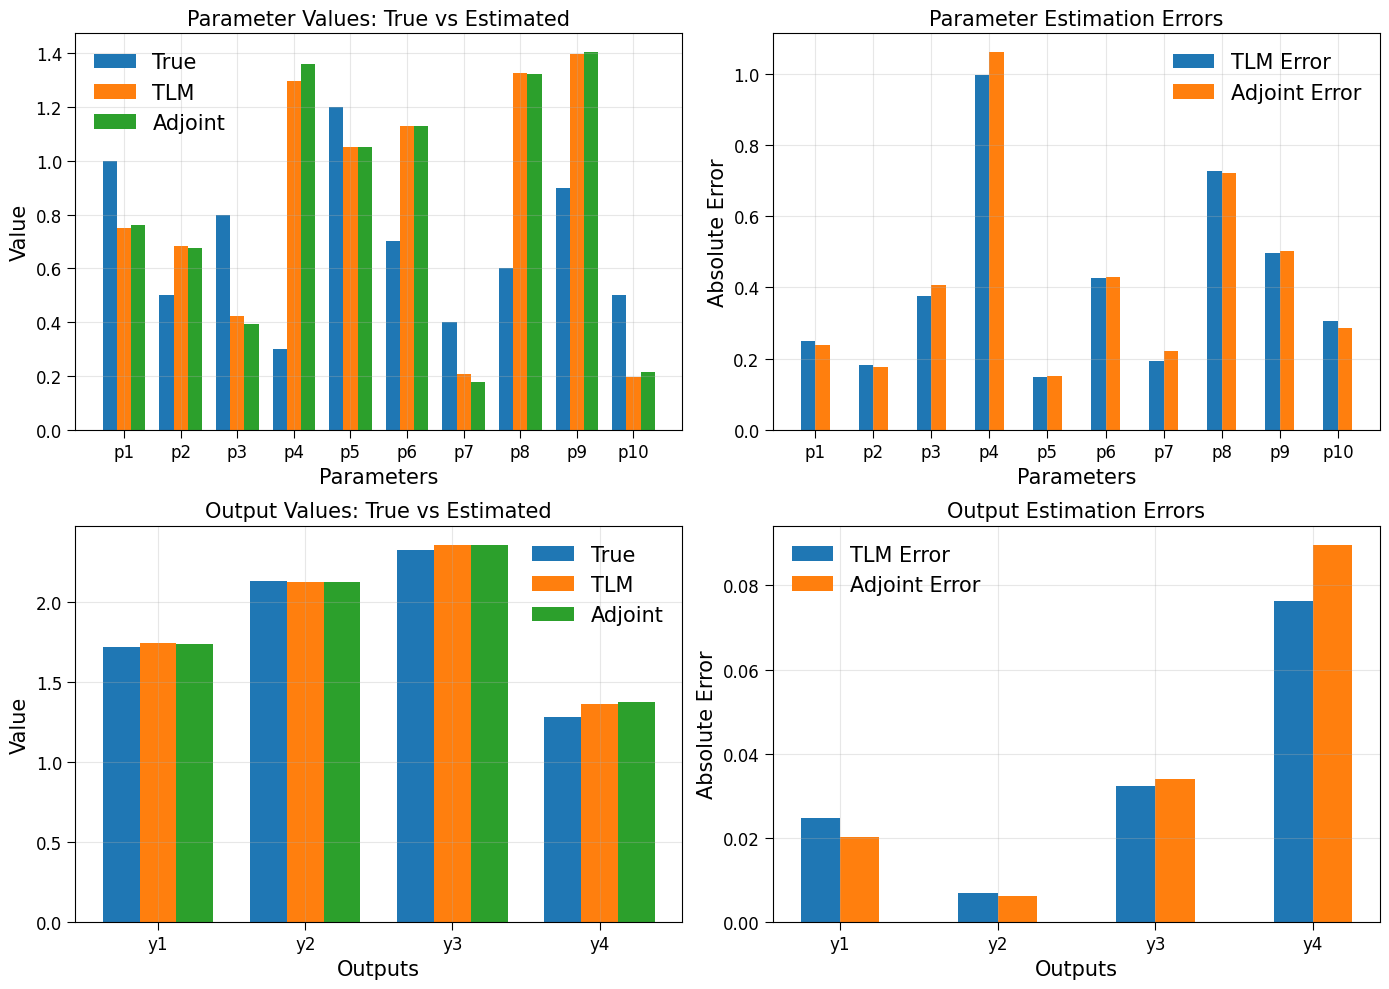

In [10]:
# Calculate final outputs
y_TLM = model(p_TLM)
y_ADJ = model(p_ADJ)

# Calculate errors
error_TLM = np.linalg.norm(p_TLM - p_true)
error_ADJ = np.linalg.norm(p_ADJ - p_true)


logger.info("Parameter Estimation Results")
logger.info("Parameter Comparison:")
logger.info(f"{'Parameter':<12} {'True':<10} {'TLM':<10} {'Adjoint':<10} {'Initial':<10}")
for i, name in enumerate(param_names):
    logger.info(f"{name:<12} {p_true[i]:<10.4f} {p_TLM[i]:<10.4f} {p_ADJ[i]:<10.4f} {p0[i]:<10.4f}")

logger.info(f"Parameter Error (L2 norm):")
logger.info(f"  Tangent Linear: {error_TLM:.6f}")
logger.info(f"  Adjoint:        {error_ADJ:.6f}")

logger.info("Output Comparison:")
logger.info(f"{'Output':<6} {'True':<10} {'TLM':<12} {'Adjoint':<12}")
for i in range(4):
    logger.info(f"y{i+1:<5} {y_true[i]:<10.4f} {y_TLM[i]:<12.6f} {y_ADJ[i]:<12.6f}")

logger.info(f"Output Error (L2 norm):")
logger.info(f"  Tangent Linear: {np.linalg.norm(y_TLM - y_true):.6f}")
logger.info(f"  Adjoint:        {np.linalg.norm(y_ADJ - y_true):.6f}")

logger.info("Summary Statistics")
# Calculate relative errors
rel_error_TLM = error_TLM / np.linalg.norm(p_true) * 100
rel_error_ADJ = error_ADJ / np.linalg.norm(p_true) * 100

logger.info(f"Relative Parameter Error (%):")
logger.info(f"  Tangent Linear: {rel_error_TLM:.2f}%")
logger.info(f"  Adjoint:        {rel_error_ADJ:.2f}%")

# Show individual parameter deviations
logger.info(f"Parameter Deviations (True - Estimated):")
logger.info(f"{'Parameter':<12} {'TLM Error':<15} {'Adjoint Error':<15}")
for i, name in enumerate(param_names):
    tlm_err = p_true[i] - p_TLM[i]
    adj_err = p_true[i] - p_ADJ[i]
    logger.info(f"{name:<12} {tlm_err:<15.6f} {adj_err:<15.6f}")

# Final visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Parameter comparison
ax = axes[0, 0]
x = np.arange(len(param_names))
width = 0.25
ax.bar(x - width, p_true, width, label='True')
ax.bar(x, p_TLM, width, label='TLM')
ax.bar(x + width, p_ADJ, width, label='Adjoint')
ax.set_xlabel('Parameters')
ax.set_ylabel('Value')
ax.set_title('Parameter Values: True vs Estimated')
ax.set_xticks(x)
ax.set_xticklabels(param_names)
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Parameter errors
ax = axes[0, 1]
errors_tlm = np.abs(p_true - p_TLM)
errors_adj = np.abs(p_true - p_ADJ)
x = np.arange(len(param_names))
ax.bar(x - width/2, errors_tlm, width, label='TLM Error')
ax.bar(x + width/2, errors_adj, width, label='Adjoint Error')
ax.set_xlabel('Parameters')
ax.set_ylabel('Absolute Error')
ax.set_title('Parameter Estimation Errors')
ax.set_xticks(x)
ax.set_xticklabels(param_names)
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Output comparison
ax = axes[1, 0]
x = np.arange(4)
ax.bar(x - width, y_true, width, label='True')
ax.bar(x, y_TLM, width, label='TLM')
ax.bar(x + width, y_ADJ, width, label='Adjoint')
ax.set_xlabel('Outputs')
ax.set_ylabel('Value')
ax.set_title('Output Values: True vs Estimated')
ax.set_xticks(x)
ax.set_xticklabels(['y1', 'y2', 'y3', 'y4'])
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Output errors
ax = axes[1, 1]
errors_tlm_y = np.abs(y_true - y_TLM)
errors_adj_y = np.abs(y_true - y_ADJ)
x = np.arange(4)
ax.bar(x - width/2, errors_tlm_y, width, label='TLM Error')
ax.bar(x + width/2, errors_adj_y, width, label='Adjoint Error')
ax.set_xlabel('Outputs')
ax.set_ylabel('Absolute Error')
ax.set_title('Output Estimation Errors')
ax.set_xticks(x)
ax.set_xticklabels(['y1', 'y2', 'y3', 'y4'])
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()